In [45]:
%pip install codecarbon


Note: you may need to restart the kernel to use updated packages.Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/516.7 kB ? eta -:--:--
   -------- ------------------------------- 112.6/516.7 kB 3.3 MB/s eta 0:00:01
   ---------------------------------------  512.0/516.7 kB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 516.7/516.7 kB 6.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ----------------- ---------------------- 0.7/1.6 MB 22.1 MB/s eta 0:00:01
   ------------------------------ --------- 1.2/1.6 MB 15.6 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 13.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/92.5 kB ? eta -:--:--
   ---------------------------------------- 92.5/92.5 kB 5.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/44.4 kB ? eta -:--:--
   -------------------------


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# tf-idf 
from sklearn.feature_extraction.text import TfidfVectorizer


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train['user_id'] = train['user_id'].str[1:].astype(int)
test['user_id'] = test['user_id'].str[1:].astype(int)
train.fillna(' ', inplace=True)
test.fillna(' ', inplace=True)


In [3]:
vectorizer = TfidfVectorizer(max_features=5000)
text_features = vectorizer.fit_transform(train['text'])
text_features_test = vectorizer.transform(test['text'])
from scipy.sparse import hstack

X_train = hstack((train[['user_id']].values, text_features))
y_train = train['label'].values
X_test = hstack((test[['user_id']].values, text_features_test))
y_test = test['label'].values




In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from codecarbon import EmissionsTracker

tracker = EmissionsTracker()
tracker.start()
clf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
clf.fit(X_train, y_train)

emissions = tracker.stop()
y_pred = clf.predict(X_test)
print(accuracy_score(y_test, y_pred))

[codecarbon INFO @ 14:01:03] [setup] RAM Tracking...
[codecarbon INFO @ 14:01:03] [setup] CPU Tracking...
[codecarbon WARNING @ 14:01:03] No CPU tracking mode found. Falling back on CPU constant mode. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 14:01:05] CPU Model on constant consumption mode: AMD Ryzen 5 5600H with Radeon Graphics
[codecarbon INFO @ 14:01:05] [setup] GPU Tracking...
[codecarbon INFO @ 14:01:05] No GPU found.
[codecarbon INFO @ 14:01:05] >>> Tracker's metadata:
[codecarbon INFO @ 14:01:05]   Platform system: Windows-10-10.0.22631-SP0
[codecarbon INFO @ 14:01:05]   Python version: 3.11.2
[codecarbon INFO @ 14:01:05]   CodeCarbon version: 2.8.3
[codecarbon INFO @ 14:01:05]   Available RAM : 13.866 GB
[codecarbon INFO @ 14:01:05]   CPU count: 12
[codecarbon INFO @ 14:01:05]   CPU model: AMD Ryzen 5 5600H with Radeon Graphics
[codecarbon INFO @ 14:01:05]   GPU count: None
[codecarbon INFO @ 14:01:05]   GPU model: None
[codeca

0.6717130895327937


In [66]:
print(classification_report(y_test, y_pred))
# auc
from sklearn.metrics import roc_auc_score
y_pred = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)

print(f"AUC-ROC Score: {auc:.4f}")





              precision    recall  f1-score   support

           0       0.63      0.93      0.75    347837
           1       0.82      0.37      0.51    299222

    accuracy                           0.67    647059
   macro avg       0.73      0.65      0.63    647059
weighted avg       0.72      0.67      0.64    647059

AUC-ROC Score: 0.7739


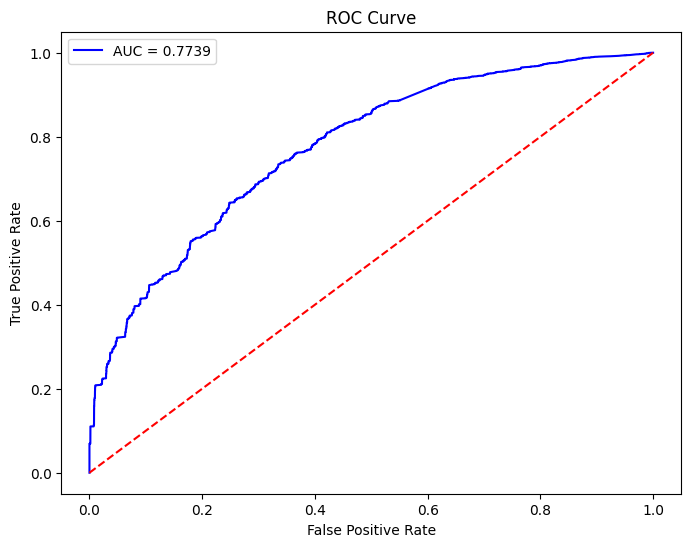

In [67]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Compute ROC curve points
fpr, tpr, _ = roc_curve(y_test, y_pred)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", color="blue")
plt.plot([0, 1], [0, 1], 'r--')  # Diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
